Hi, this is a test text with an equation: $a=b$

In [1]:


%matplotlib widget



In [1]:
import sys
print(sys.executable)


/Users/armin/Desktop/Banafshe/project/Radiotherapy-Quality-Assurance/venv/bin/python


In [15]:
# Notebook Cell 1 – Setup
%matplotlib widget
import importlib
import os
import numpy as np
import pandas as pd
from datetime import date
import field
import plotting_HK

importlib.reload(field)
importlib.reload(plotting_HK)
from field import Field
from plotting_HK import plot_segment



In [22]:
# Notebook Cell 2 – Load your test field
filename = "/Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/pre-processing_and_feature_engineering/SimpleTestField.json"
field = Field(filename)


gaps 11    2.0
12    2.0
13    2.0
14    2.0
15    2.0
16    2.0
17    2.0
18    2.0
19    2.0
20    2.0
21    2.0
22    2.0
23    2.0
24    2.0
25    2.0
26    2.0
27    2.0
28    2.0
29    2.0
30    2.0
31    2.0
32    2.0
33    2.0
34    2.0
35    2.0
36    2.0
37    2.0
38    2.0
39    2.0
40    2.0
41    2.0
42    2.0
43    2.0
44    2.0
45    2.0
46    2.0
47    2.0
48    2.0
Name: 181, dtype: float64
gaps Series([], Name: 1, dtype: int64)


In [23]:
# Notebook Cell 3 – Extract areas
Aside = field.matrixA
BSide = field.matrixB
leafgaps = Aside + BSide

leaf_widths = np.array(field.leaf_width[leafgaps.index.min()-1: leafgaps.index.max()])
areas = leafgaps.mul(leaf_widths[:, np.newaxis])


#print("✅Gantry Total Area (already correct):")
#print(field.gantry_total_areas)

print("\n Sanity Check – Sum rows of areas_matrix:")
print(field.areas_matrix.sum())
print("\n Sanity Check –:")
print(field.aperture_circumference)



 Sanity Check – Sum rows of areas_matrix:
181    38.0
1       0.0
dtype: float64

 Sanity Check –:
181    42.0
1       0.0
dtype: float64


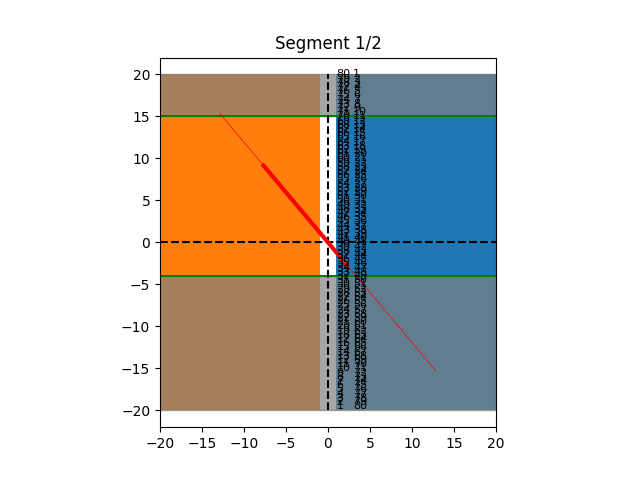

🟢 Collimator Info:
X1 = 15.0
X2 = 4.0
Y1 = None
Y2 = None
🟢 Exposed Leaf Range: 11 to 48
🟢 matrixA:
11    1.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
18    1.0
19    1.0
20    1.0
21    1.0
22    1.0
23    1.0
24    1.0
25    1.0
26    1.0
27    1.0
28    1.0
29    1.0
30    1.0
31    1.0
32    1.0
33    1.0
34    1.0
35    1.0
36    1.0
37    1.0
38    1.0
39    1.0
40    1.0
41    1.0
42    1.0
43    1.0
44    1.0
45    1.0
46    1.0
47    1.0
48    1.0
Name: 181, dtype: float64
🟢 Collimator Angle: 40
🟢 Span: -3.515454271382707 to 11.941943145691466


In [24]:
# Notebook Cell 4 – Plot one segment and show other info
segmentno = 0
plot_segment(field, segmentno)

print("🟢 Collimator Info:")
print("X1 =", field.cp[segmentno]['collimatorX1'])
print("X2 =", field.cp[segmentno]['collimatorX2'])
print("Y1 =", field.cp[segmentno]['collimatorY1'])
print("Y2 =", field.cp[segmentno]['collimatorY2'])

print("🟢 Exposed Leaf Range:", field.exposed_leaf_start[segmentno], "to", field.exposed_leaf_end[segmentno])

print("🟢 matrixA:")
print(field.matrixA.loc[
    field.exposed_leaf_start[segmentno]:field.exposed_leaf_end[segmentno],
    field.matrixA.columns[segmentno]
])

print("🟢 Collimator Angle:", field.collimatorAngle)
print("🟢 Span:", field.cp[segmentno]['spanMin'], "to", field.cp[segmentno]['spanMax'])


In [ ]:
# if you changed the code in field.py, run the above cell first
import os
from datetime import date

#datafolder = 'C:\\Users\\keller\\OneDrive - UHN\\Workfiles\\Georg Mandl\\2024-1-02'

qadate = date(2024, 1, 2)
formatted_date = qadate.strftime("%Y-%m-%d")
datafolder = 'C:\\Users\\t70105uhn\\OneDrive - UHN\\Workfiles\\Georg Mandl\\' + formatted_date

# this specific format of the date is currently created in the __main__ of RetrieveFieldData.py
# TODO: change that


if not os.path.isdir(datafolder):
    formatted_date = f"{qadate.year}-{qadate.month}-{qadate.strftime('%d')}"
    datafolder = 'C:\\Users\\t70105uhn\\OneDrive - UHN\\Workfiles\\Georg Mandl\\' + formatted_date



# example of a Varian field: (field B2 for MRN 3102335 )
# ---------------------------
# filename = datafolder+'\\'+'FieldID_2406983.json' # make sure that this available locally on the computer (and not just in the cloud)

# in order to find that out, run the file RetrieveFieldData.py with the breakpoint() set 
# Q:\VMAT QA Project\Engineered Features>python RetrieveFieldData.py 2024 01 02 and then (Pdb) selection_augmented.query("FieldID == 2406983")


# example of an Elekta field (C2 for MRN 7211873):
# --------------------------
#filename = datafolder+'\\'+'FieldID_2406771.json'

# test field with 2 control points:
# -----------
filename = '/Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/pre-processing_and_feature_engineering/SimpleTestField.json'

field = Field(filename)
# %store field



In [ ]:

import numpy as np

#print(field.cp[0]['leafSetA'])
#print(field.cp[0]['leafSetB'])

#leafposA = field.cp[0]['leafSetA']

#print(field.mq_control_points[0]['leafSetA'][field.active_leaf_start:field.active_leaf_end])
#print(field.matrixA)

# for viewing in data wrangler:
Aside = field.matrixA
BSide = field.matrixB

leafgaps = Aside+BSide



leaf_widths = np.array(field.leaf_width[leafgaps.index.min()-1: leafgaps.index.max()-1+1]) 
# just leafs matching the dataframe leafgaps, leafgaps.index indicates the leaf number starting at 1, field.leaf_width starts at index 0, the +1 makes the second index inclusive! 


areas = leafgaps.mul(leaf_widths[:, np.newaxis])

#areas[:] = 1.0 # Just to see if the summation below makes sense! 

# This trick thanks to chatGPT
ranges = {col: (field.exposed_leaf_start[areas.columns.get_loc(col)], field.exposed_leaf_end[areas.columns.get_loc(col)]) for col in areas.columns}

sums = {col: areas[col].loc[start:end].sum() for col, (start, end) in ranges.items()}

print(areas.sum()) # This was Goerge's old code 




In [ ]:
### In this cell, we are testing the plotting capabilities
### -------------------------------------------------------
#from plotting_HK import plot_segment 
# # I changed Georg's original code to use the field as the first parameter, and not field_info which is not directly returned with Field()

# have to reimport this function whenever we change the function plot_segment()
import importlib
import plotting_HK
importlib.reload(plotting_HK)

from plotting_HK import plot_segment

segmentno = 0 # with 0 the first
plot_segment(field, segmentno)

print('Collimator X1 = ', field.cp[segmentno]['collimatorX1'])
print('Collimator X2 = ', field.cp[segmentno]['collimatorX2'])
print('Collimator Y1 = ', field.cp[segmentno]['collimatorY1'])
print('Collimator Y2 = ', field.cp[segmentno]['collimatorY2'])

print(field.exposed_leaf_start[segmentno])
print(field.exposed_leaf_end[segmentno])


print(field.matrixA.loc[field.exposed_leaf_start[segmentno]:field.exposed_leaf_end[segmentno], 
                        field.matrixA.columns[segmentno]])

print(field.collimatorAngle)
print(field.cp[segmentno]['spanMin'])
print(field.cp[segmentno]['spanMax'])


In [ ]:
import os
import pandas as pd

# Path to the file
file_path = "/Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/pre-processing_and_feature_engineering/SimpleTestField.json"

# Check the file exists before trying to read it
if not os.path.isfile(file_path):
    raise FileNotFoundError(f"File not found: {file_path}")

# Load the JSON file as a DataFrame (if it's structured like metadata)
df = pd.read_json(file_path)

# Display a preview
print(df.head())


In [ ]:
%reset -f